# 04 - Texte : Modélisation Baseline

## Objectif de ce notebook
Établir une **référence de performance** en entraînant plusieurs modèles baselines sur les données texte nettoyées (prédiction du `prdtypecode` en 27 classes).

**Prérequis** : Exécuter les notebooks 01, 02 et 03 pour disposer des données dans `data/processed/`.

**Livrable** : Modèle baseline de référence (ex. SVM Linear ~78% F1-macro), vectoriseur TF-IDF et label encoder sauvegardés dans `models/`.

---

## Plan
1. Chargement des données nettoyées
2. Vectorisation des textes (TF-IDF)
3. Préparation des labels et division train/validation
4. Entraînement des modèles baselines (NB, LogReg, SVM, RF)
5. Évaluation et comparaison des modèles
6. Visualisations, matrice de confusion, analyse du meilleur modèle
7. Validation croisée et analyse des erreurs
8. Sauvegarde des modèles et recommandations pour le notebook 05



In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Affichage complet des DataFrames/arrays
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.expand_frame_repr', False)
np.set_printoptions(threshold=np.inf, linewidth=200)

# Ajouter le dossier src au path
sys.path.append(str(Path('../').resolve()))

# Import des modules de modélisation
from src.utils.data_loader import load_data
from src.modeling import TFIDFVectorizer, BaselineModels
from src.evaluation import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    plot_class_distribution
)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")



✅ Bibliothèques importées avec succès


## 1. Chargement des Données Nettoyées

Chargement des datasets préprocessés depuis `data/processed/`.


In [2]:
# Chargement des données nettoyées
DATA_DIR = Path('../data/processed')

print("🔄 Chargement des données nettoyées...")

X_train = pd.read_csv(DATA_DIR / 'X_train_clean.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_clean.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv')

# Chargement optionnel : y_train_superclass (24 classes, pour comparaison avec/sans superclasse)
y_train_superclass = None
y_train_superclass_path = DATA_DIR / 'y_train_superclass.csv'
if y_train_superclass_path.exists():
    y_train_superclass = pd.read_csv(y_train_superclass_path)
else:
    # Recréer la superclasse si le fichier n'existe pas (Publications -> 9999)
    CODE_SUPERCLASSE = 9999
    PUBLICATIONS_CLASSES = {10, 2280, 2403, 2705}
    y_train_superclass = y_train.copy()
    y_train_superclass['prdtypecode'] = y_train['prdtypecode'].apply(
        lambda x: CODE_SUPERCLASSE if x in PUBLICATIONS_CLASSES else x
    )
    # Sauvegarder pour les prochaines exécutions
    y_train_superclass.to_csv(y_train_superclass_path, index=False)
    print("⚠️ y_train_superclass.csv introuvable : superclasse recréée et sauvegardée.")

print(f"✅ Données chargées avec succès !")
print(f"\n📊 Dimensions des datasets :")
print(f"  - X_train : {X_train.shape[0]:,} lignes × {X_train.shape[1]} colonnes")
print(f"  - X_test  : {X_test.shape[0]:,} lignes × {X_test.shape[1]} colonnes")
print(f"  - y_train : {y_train.shape[0]:,} lignes × {y_train.shape[1]} colonnes")
if y_train_superclass is not None:
    print(f"  - y_train_superclass : {y_train_superclass.shape[0]:,} lignes × {y_train_superclass.shape[1]} colonnes")

# Vérification
print(f"\n✅ Vérifications :")
print(f"  - Alignement X_train/y_train : {X_train.shape[0] == y_train.shape[0]}")
print(f"  - Colonne text_combined présente : {'text_combined' in X_train.columns}")
print(f"  - Nombre de classes : {y_train['prdtypecode'].nunique()}")
if y_train_superclass is not None:
    print(f"  - Nombre de classes (superclass) : {y_train_superclass['prdtypecode'].nunique()}")

# Aperçu
print(f"\n📝 Aperçu des données :")
print(f"  - Exemple de texte combiné (premiers 200 caractères) :")
print(f"    {X_train['text_combined'].iloc[0][:200]}...")



🔄 Chargement des données nettoyées...
✅ Données chargées avec succès !

📊 Dimensions des datasets :
  - X_train : 84,916 lignes × 17 colonnes
  - X_test  : 13,812 lignes × 17 colonnes
  - y_train : 84,916 lignes × 2 colonnes
  - y_train_superclass : 84,916 lignes × 2 colonnes

✅ Vérifications :
  - Alignement X_train/y_train : True
  - Colonne text_combined présente : True
  - Nombre de classes : 27
  - Nombre de classes (superclass) : 24

📝 Aperçu des données :
  - Exemple de texte combiné (premiers 200 caractères) :
    olivia: personalisiertes notizbuch / 150 seiten / punktraster / ca din a5 / rosen-design...


## 2. Vectorisation des Textes (TF-IDF)

Transformation des textes en vecteurs numériques pour la modélisation.


In [3]:
# Préparation des textes
X_train_texts = X_train['text_combined'].astype(str)
X_test_texts = X_test['text_combined'].astype(str)

print("🔄 Vectorisation TF-IDF...")
print(f"  - Nombre de textes d'entraînement : {len(X_train_texts):,}")
print(f"  - Nombre de textes de test : {len(X_test_texts):,}")

# Création et entraînement du vectoriseur
vectorizer = TFIDFVectorizer(
    max_features=10000,      # Limiter le vocabulaire à 10 000 mots
    min_df=2,                 # Mots apparaissant au moins 2 fois
    max_df=0.95,              # Mots apparaissant dans max 95% des documents
    ngram_range=(1, 2),       # Unigrams et bigrams
    lowercase=True,
    stop_words='french'       # Stop words français
)

# Entraînement sur les données d'entraînement uniquement
X_train_vect = vectorizer.fit_transform(X_train_texts)
X_test_vect = vectorizer.transform(X_test_texts)

print(f"✅ Vectorisation terminée !")
print(f"\n📊 Caractéristiques des vecteurs :")
print(f"  - Taille du vocabulaire : {vectorizer.get_vocabulary_size():,} mots")
print(f"  - Dimensions X_train_vect : {X_train_vect.shape}")
print(f"  - Dimensions X_test_vect : {X_test_vect.shape}")
print(f"  - Densité (sparsity) : {(1 - X_train_vect.nnz / (X_train_vect.shape[0] * X_train_vect.shape[1])) * 100:.2f}%")



🔄 Vectorisation TF-IDF...
  - Nombre de textes d'entraînement : 84,916
  - Nombre de textes de test : 13,812
✅ Vectorisation terminée !

📊 Caractéristiques des vecteurs :
  - Taille du vocabulaire : 10,000 mots
  - Dimensions X_train_vect : (84916, 10000)
  - Dimensions X_test_vect : (13812, 10000)
  - Densité (sparsity) : 99.55%


## 3. Préparation des Labels

Encodage des labels pour la modélisation.


In [4]:
# Extraction des labels
y_train_labels = y_train['prdtypecode'].values

# Encodage des labels (déjà numériques, mais on s'assure qu'ils sont bien encodés)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_labels)

# Encodage superclasse (24 classes) si disponible
label_encoder_superclass = None
y_train_encoded_sc = None
if y_train_superclass is not None:
    label_encoder_superclass = LabelEncoder()
    y_train_encoded_sc = label_encoder_superclass.fit_transform(
        y_train_superclass['prdtypecode'].values
    )

# Fonction d'affichage des stats pour un scénario
def print_label_stats(scenario_name: str, y_encoded: np.ndarray, encoder: LabelEncoder) -> None:
    print(f"\n📊 Préparation des labels - {scenario_name} :")
    print(f"  - Nombre de classes : {len(encoder.classes_)}")
    print(f"  - Classes : {sorted(encoder.classes_)}")
    print(f"  - Distribution des classes (top 10) :")
    class_counts = pd.Series(y_encoded).value_counts().head(10)
    for idx, count in class_counts.items():
        original_class = encoder.inverse_transform([idx])[0]
        print(f"    Classe {original_class} : {count} occurrences ({count/len(y_encoded)*100:.2f}%)")

# Affichage des stats pour les 27 classes
print_label_stats("27 classes", y_train_encoded, label_encoder)

# Affichage des stats pour la superclasse si dispo
if y_train_encoded_sc is not None:
    print_label_stats("24 classes (superclass)", y_train_encoded_sc, label_encoder_superclass)
    print(f"\n✅ Superclasse chargée : {len(label_encoder_superclass.classes_)} classes")

# Sauvegarde des label encoders pour plus tard
import pickle
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
with open(MODELS_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"\n✅ Label encoder sauvegardé dans {MODELS_DIR / 'label_encoder.pkl'}")
if label_encoder_superclass is not None:
    with open(MODELS_DIR / 'label_encoder_superclass.pkl', 'wb') as f:
        pickle.dump(label_encoder_superclass, f)
    print(f"✅ Label encoder superclasse sauvegardé dans {MODELS_DIR / 'label_encoder_superclass.pkl'}")

# Définition des scénarios (avec et sans superclasse)
SCENARIOS = [("27 classes", y_train_encoded, label_encoder)]
if y_train_encoded_sc is not None:
    SCENARIOS.append(("24 classes (superclass)", y_train_encoded_sc, label_encoder_superclass))

print(f"\n✅ Scénarios à tester : {[s[0] for s in SCENARIOS]}")




📊 Préparation des labels - 27 classes :
  - Nombre de classes : 27
  - Classes : [np.int64(10), np.int64(40), np.int64(50), np.int64(60), np.int64(1140), np.int64(1160), np.int64(1180), np.int64(1280), np.int64(1281), np.int64(1300), np.int64(1301), np.int64(1302), np.int64(1320), np.int64(1560), np.int64(1920), np.int64(1940), np.int64(2060), np.int64(2220), np.int64(2280), np.int64(2403), np.int64(2462), np.int64(2522), np.int64(2582), np.int64(2583), np.int64(2585), np.int64(2705), np.int64(2905)]
  - Distribution des classes (top 10) :
    Classe 2583 : 10209 occurrences (12.02%)
    Classe 1560 : 5073 occurrences (5.97%)
    Classe 1300 : 5045 occurrences (5.94%)
    Classe 2060 : 4993 occurrences (5.88%)
    Classe 2522 : 4989 occurrences (5.88%)
    Classe 1280 : 4870 occurrences (5.74%)
    Classe 2403 : 4774 occurrences (5.62%)
    Classe 2280 : 4760 occurrences (5.61%)
    Classe 1920 : 4303 occurrences (5.07%)
    Classe 1160 : 3953 occurrences (4.66%)

📊 Préparation des la

## 4. Division Train/Validation

Création d'un ensemble de validation pour évaluer les modèles.


In [5]:
# Division train/validation (80/20) - mêmes indices pour tous les scénarios
indices = np.arange(X_train_vect.shape[0])
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded  # Conserver la distribution des classes
)

X_train_split = X_train_vect[train_idx]
X_val_split = X_train_vect[val_idx]

print("📊 Division Train/Validation :")
print(f"  - Train : {X_train_split.shape[0]:,} échantillons")
print(f"  - Validation : {X_val_split.shape[0]:,} échantillons")
print(f"  - Ratio : {X_train_split.shape[0] / X_val_split.shape[0]:.2f}")

# Construire les splits pour chaque scénario
splits_by_scenario = {}
for scenario_name, y_encoded, _ in SCENARIOS:
    y_train_split = y_encoded[train_idx]
    y_val_split = y_encoded[val_idx]
    splits_by_scenario[scenario_name] = (X_train_split, X_val_split, y_train_split, y_val_split)

    # Vérification de la distribution des classes
    print(f"\n✅ Distribution des classes (validation) - {scenario_name} :")
    val_class_counts = pd.Series(y_val_split).value_counts()
    print(f"  - Nombre de classes représentées : {len(val_class_counts)}")
    print(f"  - Classe la plus fréquente : {val_class_counts.max()} occurrences")
    print(f"  - Classe la moins fréquente : {val_class_counts.min()} occurrences")



📊 Division Train/Validation :
  - Train : 67,932 échantillons
  - Validation : 16,984 échantillons
  - Ratio : 4.00

✅ Distribution des classes (validation) - 27 classes :
  - Nombre de classes représentées : 27
  - Classe la plus fréquente : 2042 occurrences
  - Classe la moins fréquente : 153 occurrences

✅ Distribution des classes (validation) - 24 classes (superclass) :
  - Nombre de classes représentées : 24
  - Classe la plus fréquente : 3082 occurrences
  - Classe la moins fréquente : 153 occurrences


## 5. Entraînement des Modèles Baselines

Entraînement de plusieurs modèles baselines pour comparer leurs performances.


In [6]:
# Entraînement des modèles baselines (avec et sans superclasse)
trained_models = {}

for scenario_name, _, _ in SCENARIOS:
    baseline_models = BaselineModels(random_state=42)
    models = baseline_models.create_baseline_models()

    print(f"\n📋 Modèles baselines créés ({scenario_name}) :")
    for model_name in models.keys():
        print(f"  - {model_name}")

    print(f"\n🔄 Entraînement des modèles ({scenario_name})...")
    print("="*80)

    # Entraînement de tous les modèles
    import time
    start_time = time.time()
    X_train_split, X_val_split, y_train_split, y_val_split = splits_by_scenario[scenario_name]
    scenario_trained = baseline_models.train_all_models(X_train_split, y_train_split)
    elapsed = time.time() - start_time
    print(f"Temps d'entraînement : {elapsed} secondes")

    # Stocker les modèles entraînés
    for model_name, model in scenario_trained.items():
        trained_models[(scenario_name, model_name)] = model

    print("\n" + "="*80)
    print(f"✅ Tous les modèles ont été entraînés avec succès ({scenario_name}) !")

print("\n✅ Entraînements terminés pour tous les scénarios.")




📋 Modèles baselines créés (27 classes) :
  - Naive Bayes
  - Logistic Regression
  - SVM (Linear)
  - Random Forest

🔄 Entraînement des modèles (27 classes)...
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Random Forest...
✅ Random Forest entraîné avec succès
Temps d'entraînement : 23.202622890472412 secondes

✅ Tous les modèles ont été entraînés avec succès (27 classes) !

📋 Modèles baselines créés (24 classes (superclass)) :
  - Naive Bayes
  - Logistic Regression
  - SVM (Linear)
  - Random Forest

🔄 Entraînement des modèles (24 classes (superclass))...
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Ra

## 6. Évaluation des Modèles

Évaluation des modèles sur l'ensemble de validation avec des métriques adaptées au déséquilibre.


In [7]:
# Prédictions sur l'ensemble de validation
print("="*80)
print("ÉVALUATION DES MODÈLES SUR L'ENSEMBLE DE VALIDATION")
print("="*80)

results_summary = []

for (scenario_name, model_name), model in trained_models.items():
    print(f"\n{'='*80}")
    print(f"Modèle : {model_name} ({scenario_name})")
    print(f"{'='*80}")

    # Récupérer le split correspondant
    X_train_split, X_val_split, y_train_split, y_val_split = splits_by_scenario[scenario_name]

    # Prédictions
    y_pred = model.predict(X_val_split)

    # Évaluation
    metrics = evaluate_model(y_val_split, y_pred)

    # Afficher les métriques
    print(f"\n📊 Métriques :")
    print(f"  - Accuracy : {metrics['accuracy']:.4f}")
    print(f"  - Precision (macro) : {metrics['precision_macro']:.4f}")
    print(f"  - Recall (macro) : {metrics['recall_macro']:.4f}")
    print(f"  - F1-score (macro) : {metrics['f1_macro']:.4f}")
    print(f"  - F1-score (weighted) : {metrics['f1_weighted']:.4f}")

    # Stocker les résultats
    results_summary.append({
        'Scenario': scenario_name,
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'F1_macro': metrics['f1_macro'],
        'F1_weighted': metrics['f1_weighted'],
        'Precision_macro': metrics['precision_macro'],
        'Recall_macro': metrics['recall_macro']
    })

# Créer un DataFrame de comparaison
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(['Scenario', 'Model']).reset_index(drop=True)

print(f"\n{'='*80}")
print("COMPARAISON DES MODÈLES")
print(f"{'='*80}")

# Forcer l'affichage complet (évite la troncature)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Tableau complet
print(results_df.to_string(index=False))

# Tableaux séparés par scénario
for scenario in results_df['Scenario'].unique():
    print(f"\n{'-'*80}")
    print(f"TABLEAU RÉSULTATS - {scenario}")
    print(f"{'-'*80}")
    scenario_df = results_df[results_df['Scenario'] == scenario]
    print(scenario_df.to_string(index=False))



ÉVALUATION DES MODÈLES SUR L'ENSEMBLE DE VALIDATION

Modèle : Naive Bayes (27 classes)

📊 Métriques :
  - Accuracy : 0.7277
  - Precision (macro) : 0.7734
  - Recall (macro) : 0.6675
  - F1-score (macro) : 0.6950
  - F1-score (weighted) : 0.7178

Modèle : Logistic Regression (27 classes)

📊 Métriques :
  - Accuracy : 0.7912
  - Precision (macro) : 0.7979
  - Recall (macro) : 0.7561
  - F1-score (macro) : 0.7718
  - F1-score (weighted) : 0.7907

Modèle : SVM (Linear) (27 classes)

📊 Métriques :
  - Accuracy : 0.8023
  - Precision (macro) : 0.7948
  - Recall (macro) : 0.7787
  - F1-score (macro) : 0.7847
  - F1-score (weighted) : 0.8015

Modèle : Random Forest (27 classes)

📊 Métriques :
  - Accuracy : 0.5293
  - Precision (macro) : 0.7739
  - Recall (macro) : 0.4167
  - F1-score (macro) : 0.4598
  - F1-score (weighted) : 0.5107

Modèle : Naive Bayes (24 classes (superclass))

📊 Métriques :
  - Accuracy : 0.7724
  - Precision (macro) : 0.8154
  - Recall (macro) : 0.6685
  - F1-score (mac

### 6.1 Visualisation des Performances


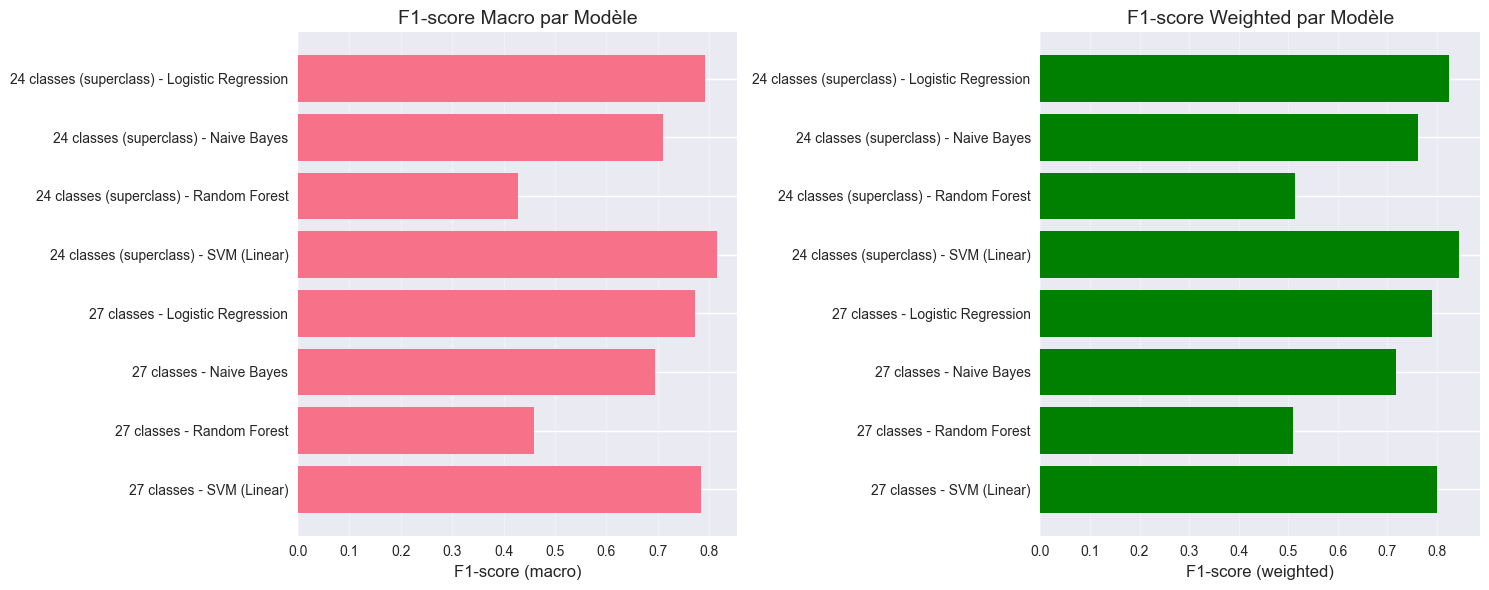

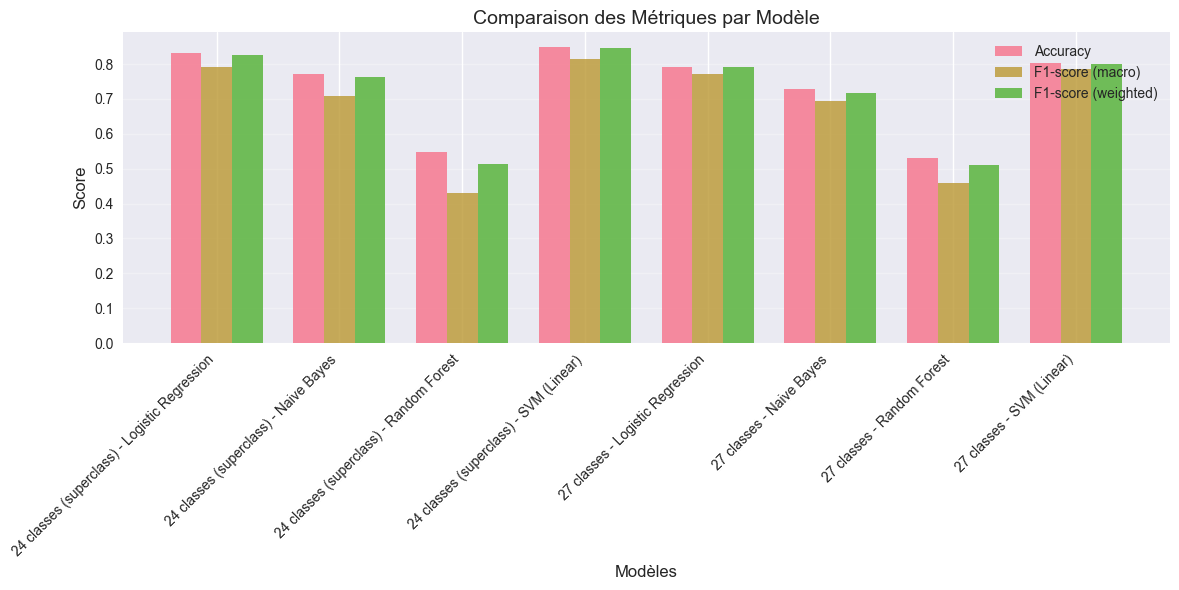

In [8]:
# Graphique de comparaison des modèles
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

labels = results_df['Scenario'] + ' - ' + results_df['Model']

# F1-score macro
axes[0].barh(labels, results_df['F1_macro'])
axes[0].set_xlabel('F1-score (macro)', fontsize=12)
axes[0].set_title('F1-score Macro par Modèle', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# F1-score weighted
axes[1].barh(labels, results_df['F1_weighted'], color='green')
axes[1].set_xlabel('F1-score (weighted)', fontsize=12)
axes[1].set_title('F1-score Weighted par Modèle', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, results_df['F1_macro'], width, label='F1-score (macro)', alpha=0.8)
ax.bar(x + width, results_df['F1_weighted'], width, label='F1-score (weighted)', alpha=0.8)

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Métriques par Modèle', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.2 Analyse Détaillée du Meilleur Modèle

Analyse approfondie du modèle le plus performant.


In [9]:
# Identifier le meilleur modèle par scénario (basé sur F1-score macro)
best_rows = results_df.loc[results_df.groupby('Scenario')['F1_macro'].idxmax()].reset_index(drop=True)
best_by_scenario = {}

for _, row in best_rows.iterrows():
    scenario = row['Scenario']
    model_name = row['Model']

    print(f"🏆 Meilleur modèle : {model_name} ({scenario})")
    print(f"   F1-score (macro) : {row['F1_macro']:.4f}")
    print(f"   F1-score (weighted) : {row['F1_weighted']:.4f}")

    # Prédictions du meilleur modèle
    X_train_split, X_val_split, y_train_split, y_val_split = splits_by_scenario[scenario]
    model = trained_models[(scenario, model_name)]
    y_pred = model.predict(X_val_split)

    # Label encoder du scénario
    label_encoder_best = next(enc for name, _, enc in SCENARIOS if name == scenario)
    class_names = [f"Classe {cls}" for cls in sorted(label_encoder_best.classes_)]

    best_by_scenario[scenario] = {
        'model_name': model_name,
        'model': model,
        'y_val': y_val_split,
        'y_pred': y_pred,
        'label_encoder': label_encoder_best,
        'class_names': class_names,
        'metrics': row
    }

    # Rapport de classification détaillé
    print(f"\n{'='*80}")
    print(f"RAPPORT DE CLASSIFICATION DÉTAILLÉ - {model_name} ({scenario})")
    print(f"{'='*80}")
    print_classification_report(y_val_split, y_pred)
    print("\n")



🏆 Meilleur modèle : SVM (Linear) (24 classes (superclass))
   F1-score (macro) : 0.8145
   F1-score (weighted) : 0.8452

RAPPORT DE CLASSIFICATION DÉTAILLÉ - SVM (Linear) (24 classes (superclass))
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

           0       0.78      0.60      0.67       502
           1       0.78      0.79      0.79       336
           2       0.95      0.83      0.89       166
           3       0.74      0.77      0.75       534
           4       0.90      0.89      0.90       791
           5       0.70      0.46      0.56       153
           6       0.74      0.67      0.70       974
           7       0.65      0.48      0.55       414
           8       0.88      0.92      0.90      1009
           9       0.95      0.94      0.94       161
          10       0.82      0.76      0.79       498
          11       0.79      0.75      0.77       648
          12       0.84      0.83      0.83      1015
          13       0

### 6.3 Matrice de Confusion

Visualisation de la matrice de confusion pour identifier les classes confondues.


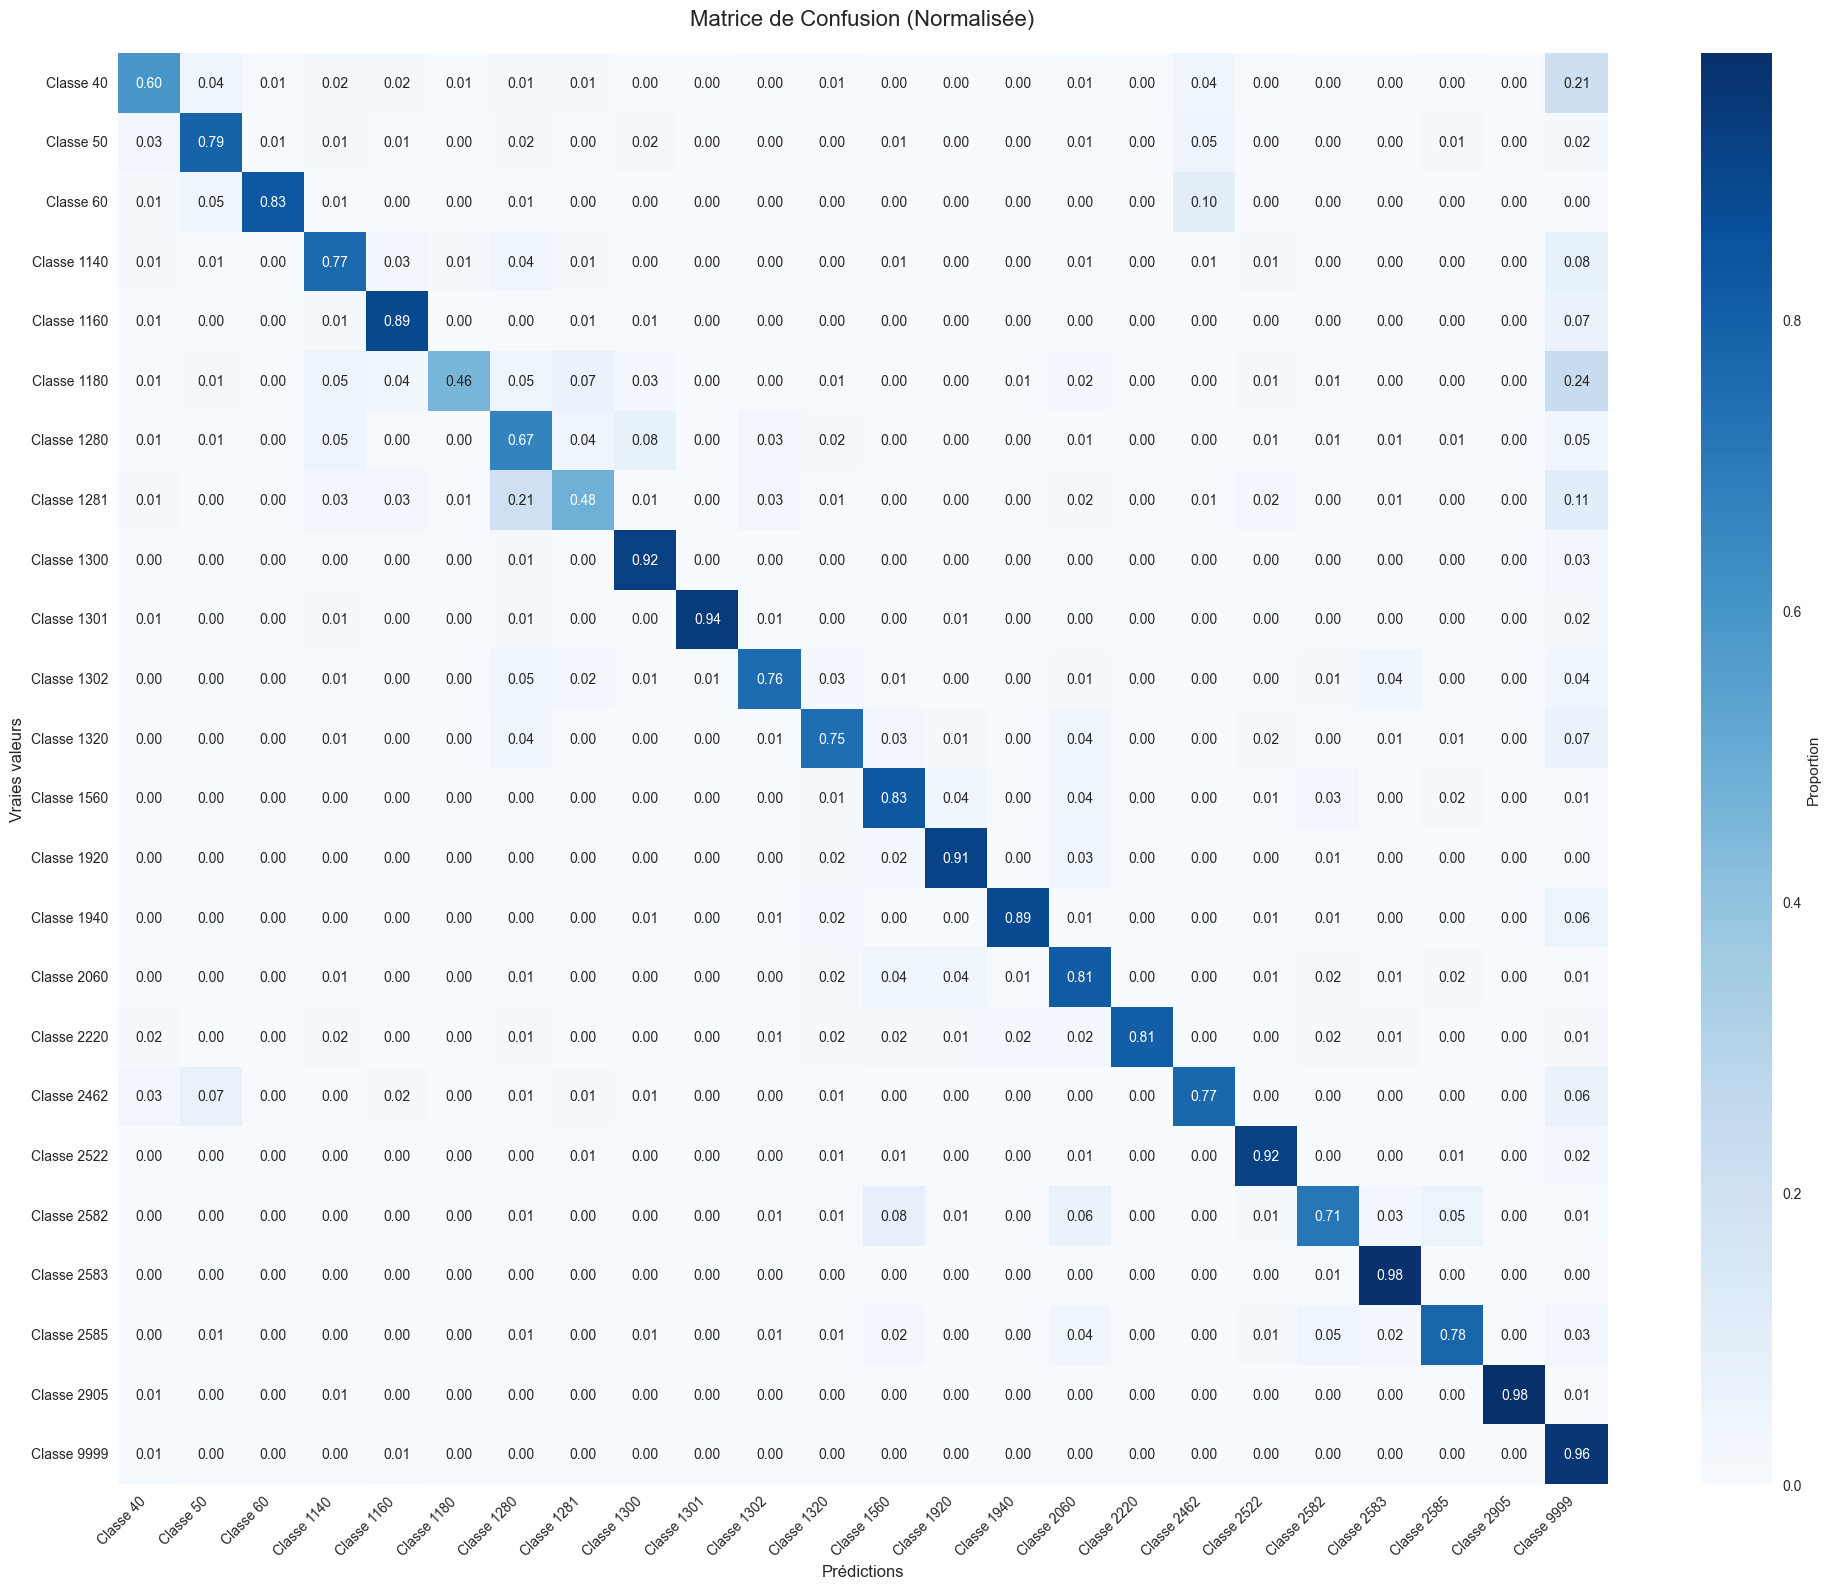

Matrice de confusion - SVM (Linear) (24 classes (superclass))


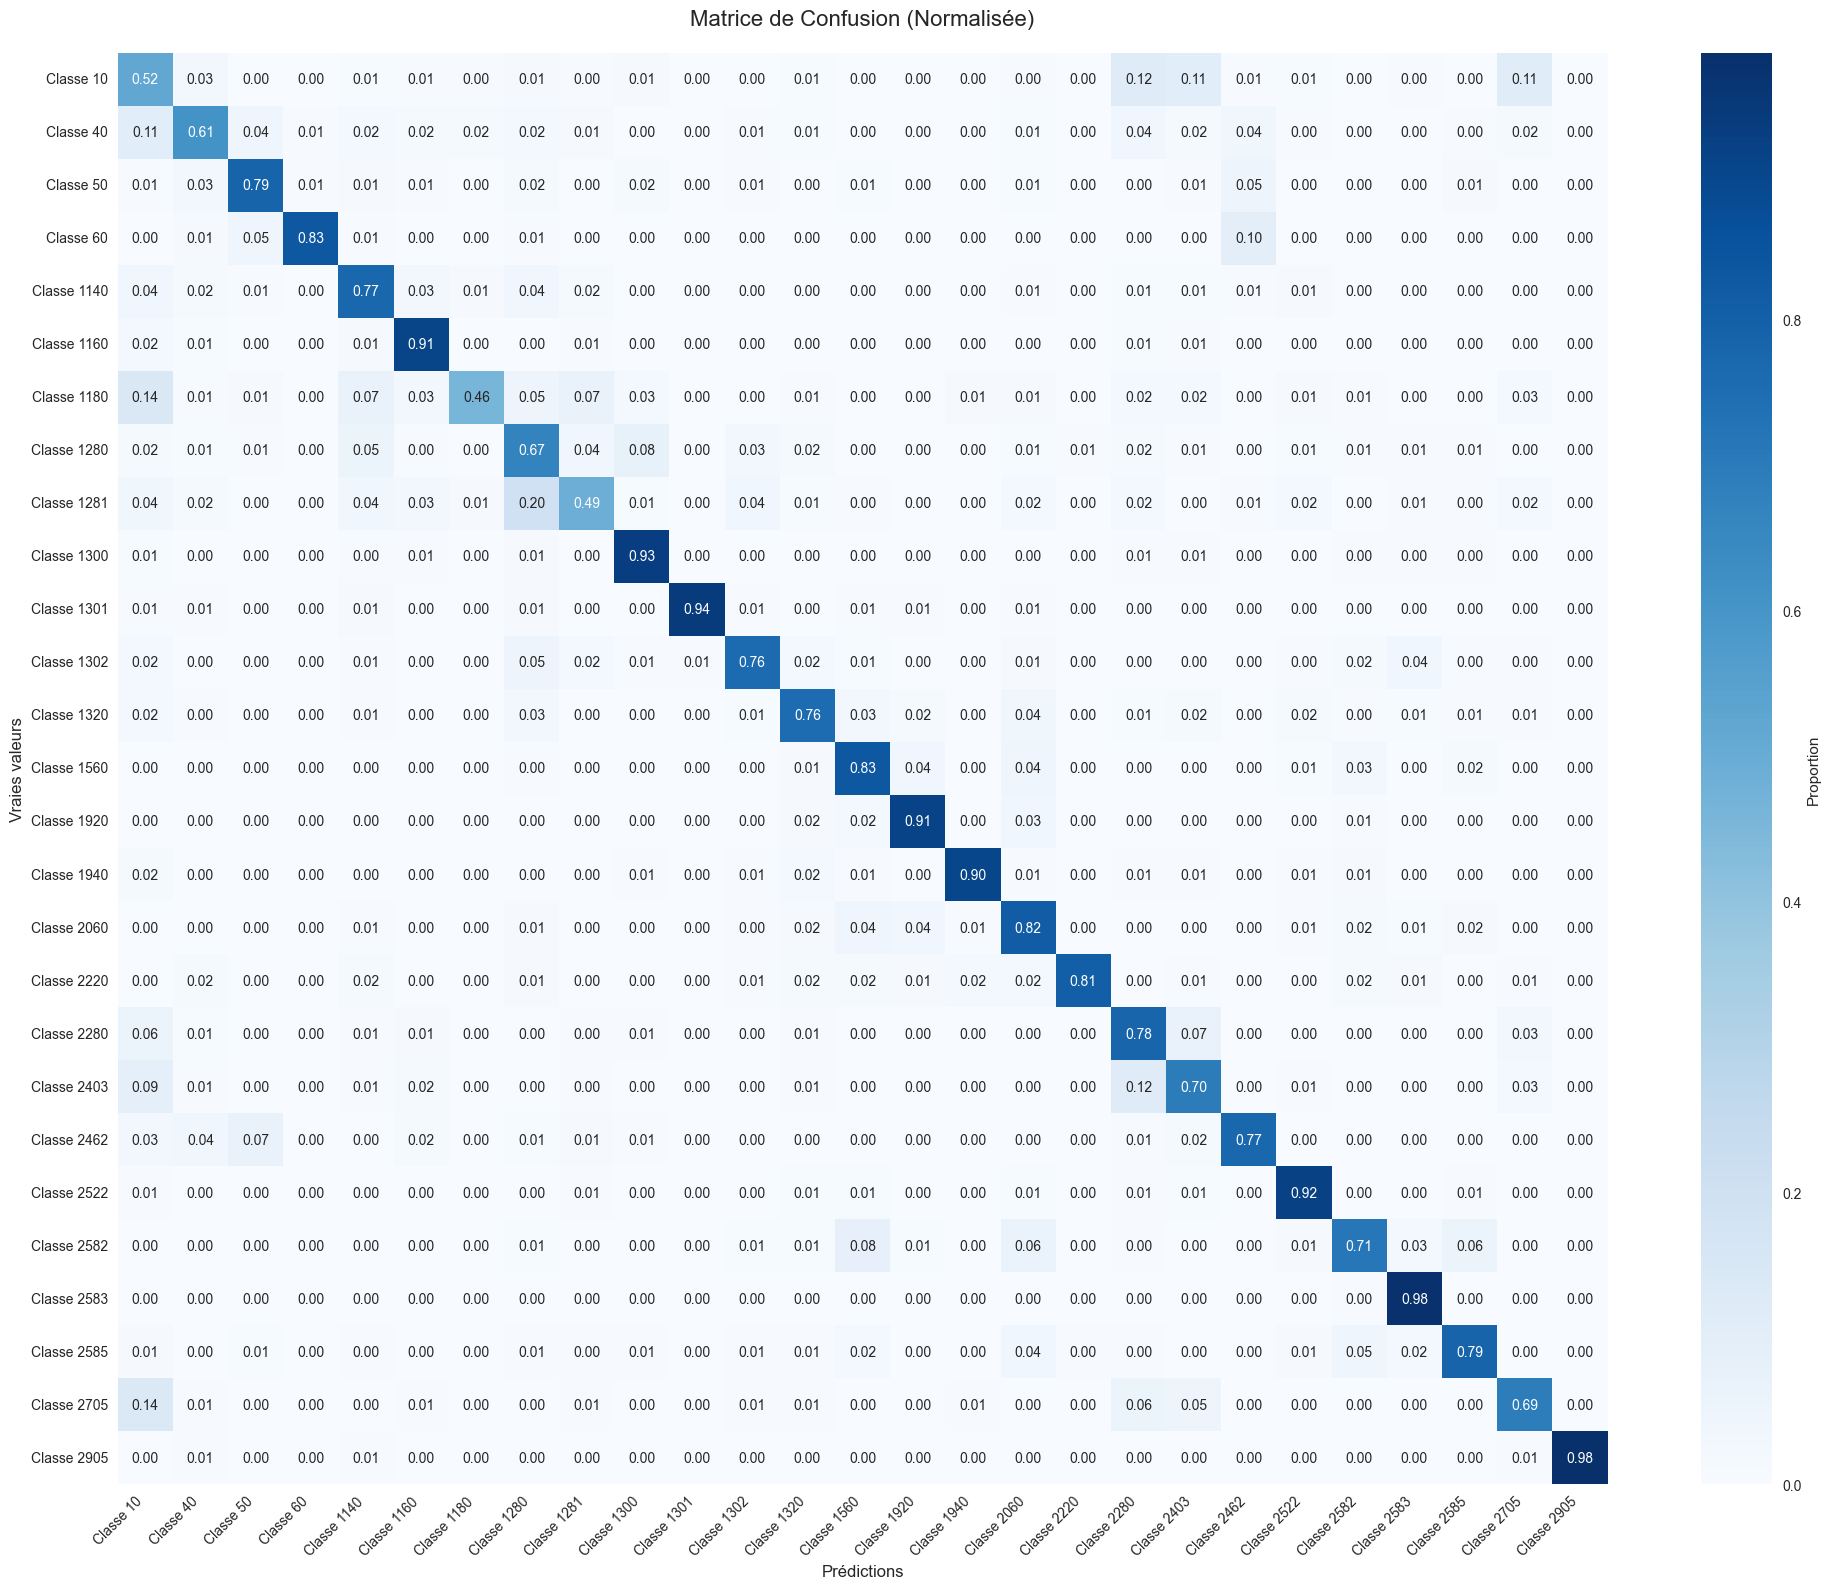

Matrice de confusion - SVM (Linear) (27 classes)


In [10]:
# Matrices de confusion pour chaque scénario
for scenario, data in best_by_scenario.items():
    model_name = data['model_name']
    plot_confusion_matrix(
        data['y_val'],
        data['y_pred'],
        class_names=data['class_names'],
        figsize=(20, 16),
        normalize=True
    )
    print(f"Matrice de confusion - {model_name} ({scenario})")



### 6.4 Distribution des Classes : Réel vs Prédit

Comparaison de la distribution des classes réelles et prédites.


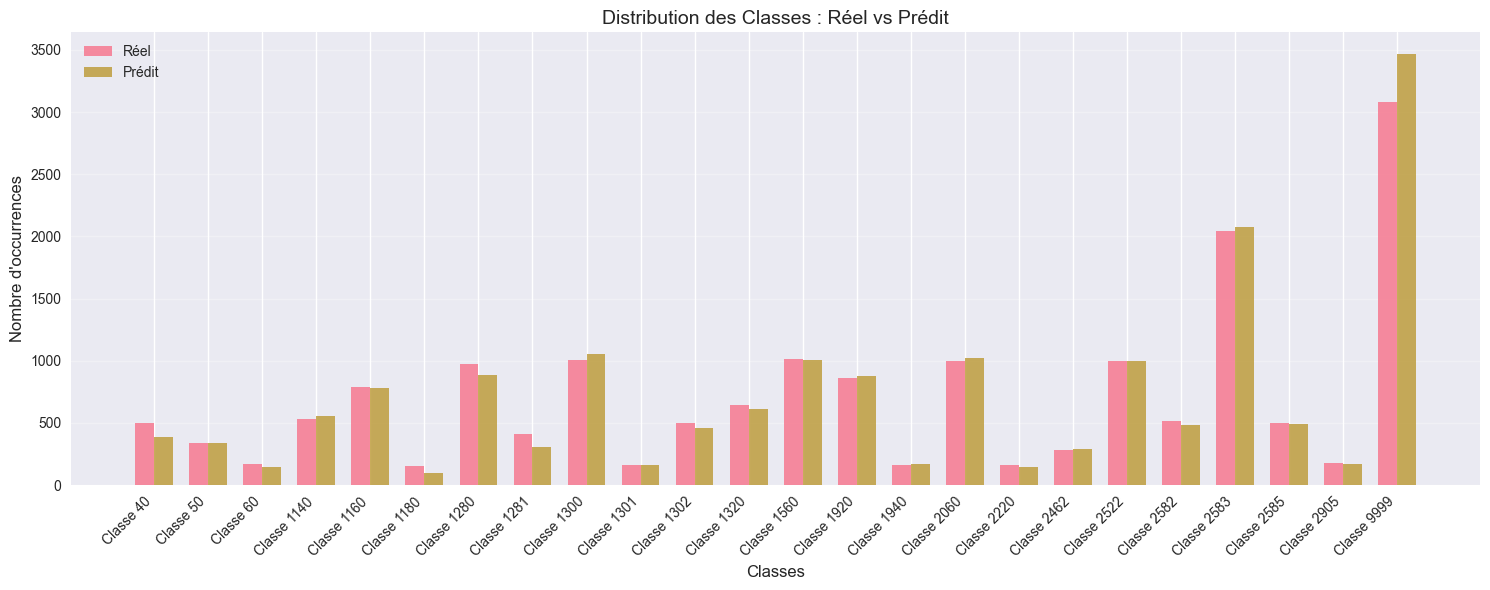

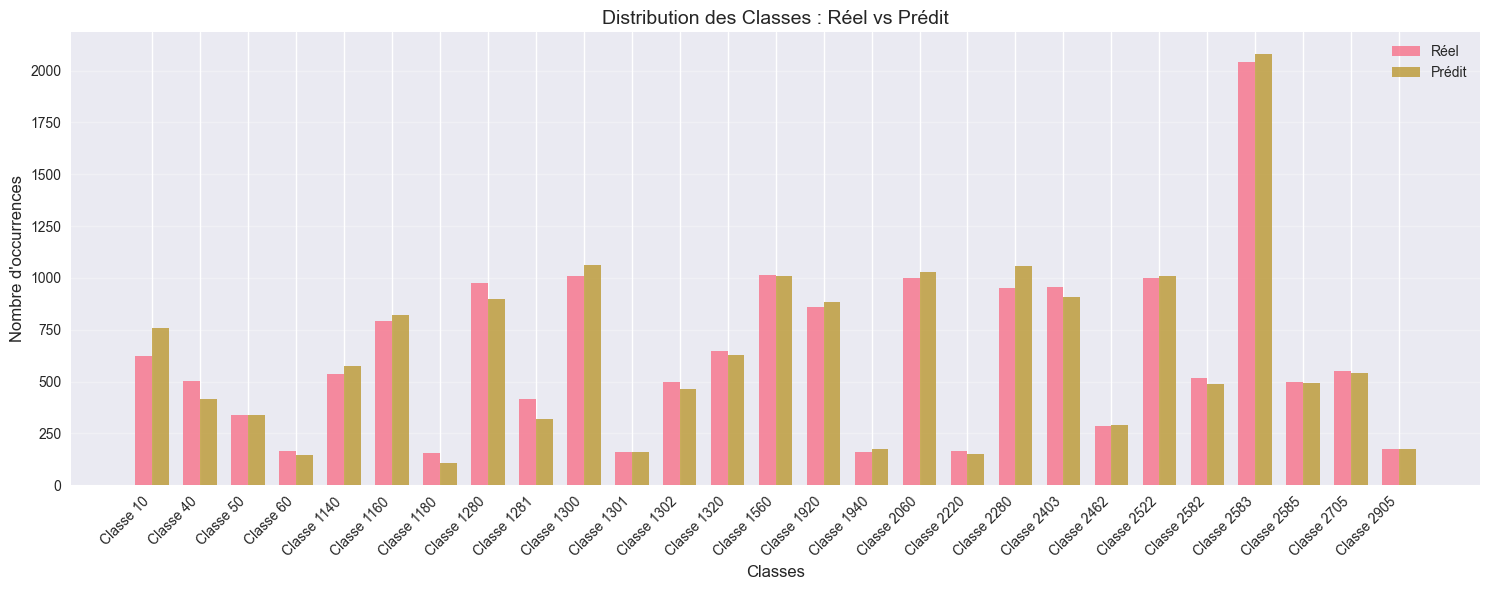

In [11]:
# Distribution des classes par scénario
for scenario, data in best_by_scenario.items():
    plot_class_distribution(data['y_val'], data['y_pred'], class_names=data['class_names'])



## 7. Validation Croisée

Validation croisée pour obtenir une estimation plus robuste des performances.


In [12]:
# Validation croisée sur les modèles (5 folds)
print("="*80)
print("VALIDATION CROISÉE (5 folds)")
print("="*80)

cv_results = []

for scenario_name, y_encoded, _ in SCENARIOS:
    baseline_models = BaselineModels(random_state=42)
    models = baseline_models.create_baseline_models()

    for model_name in models.keys():
        print(f"\n🔄 Validation croisée pour {model_name} ({scenario_name})...")
        cv_result = baseline_models.cross_validate(
            model_name,
            X_train_vect,
            y_encoded,
            cv=5,
            scoring='f1_macro'
        )
        cv_results.append({
            'Scenario': scenario_name,
            'Model': model_name,
            'CV_F1_mean': cv_result['mean'],
            'CV_F1_std': cv_result['std']
        })
        print(f"  - F1-score (macro) moyen : {cv_result['mean']:.4f} (+/- {cv_result['std']*2:.4f})")

# Comparaison des résultats de validation croisée
print(f"\n{'='*80}")
print("RÉSULTATS DE VALIDATION CROISÉE")
print(f"{'='*80}")
cv_summary = pd.DataFrame(cv_results).sort_values('CV_F1_mean', ascending=False)

# Forcer l'affichage complet (évite la troncature)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(cv_summary.to_string(index=False))



VALIDATION CROISÉE (5 folds)

🔄 Validation croisée pour Naive Bayes (27 classes)...
  - F1-score (macro) moyen : 0.6906 (+/- 0.0103)

🔄 Validation croisée pour Logistic Regression (27 classes)...
  - F1-score (macro) moyen : 0.7675 (+/- 0.0100)

🔄 Validation croisée pour SVM (Linear) (27 classes)...
  - F1-score (macro) moyen : 0.7811 (+/- 0.0058)

🔄 Validation croisée pour Random Forest (27 classes)...
  - F1-score (macro) moyen : 0.4638 (+/- 0.0115)

🔄 Validation croisée pour Naive Bayes (24 classes (superclass))...
  - F1-score (macro) moyen : 0.7043 (+/- 0.0085)

🔄 Validation croisée pour Logistic Regression (24 classes (superclass))...
  - F1-score (macro) moyen : 0.7875 (+/- 0.0091)

🔄 Validation croisée pour SVM (Linear) (24 classes (superclass))...
  - F1-score (macro) moyen : 0.8071 (+/- 0.0063)

🔄 Validation croisée pour Random Forest (24 classes (superclass))...
  - F1-score (macro) moyen : 0.4304 (+/- 0.0077)

RÉSULTATS DE VALIDATION CROISÉE
               Scenario         

## 8. Analyse des Erreurs

Analyse des erreurs de classification pour identifier les patterns et axes d'amélioration.


In [13]:
# Analyse des erreurs pour chaque scénario
for scenario, data in best_by_scenario.items():
    model_name = data['model_name']
    y_val = data['y_val']
    y_pred = data['y_pred']
    label_encoder_best = data['label_encoder']

    errors_mask = y_val != y_pred
    n_errors = errors_mask.sum()
    n_total = len(y_val)

    print(f"📊 Analyse des Erreurs - {model_name} ({scenario})")
    print(f"{'='*80}")
    print(f"  - Nombre total d'échantillons : {n_total:,}")
    print(f"  - Nombre d'erreurs : {n_errors:,}")
    print(f"  - Taux d'erreur : {n_errors/n_total*100:.2f}%")
    print(f"  - Taux de réussite : {(1-n_errors/n_total)*100:.2f}%")

    # Analyse par classe : quelles classes sont le plus souvent confondues ?
    print(f"\n📊 Confusions les plus fréquentes :")
    confusion_pairs = []
    for true_label, pred_label in zip(y_val[errors_mask], y_pred[errors_mask]):
        true_class = label_encoder_best.inverse_transform([true_label])[0]
        pred_class = label_encoder_best.inverse_transform([pred_label])[0]
        confusion_pairs.append((true_class, pred_class))

    if confusion_pairs:
        confusion_df = pd.Series(confusion_pairs).value_counts().head(10)
        print("\nTop 10 confusions :")
        for (true_class, pred_class), count in confusion_df.items():
            print(f"  {true_class} → {pred_class} : {count} fois")
    else:
        print("  Aucune confusion détectée.")

    print("\n")



📊 Analyse des Erreurs - SVM (Linear) (24 classes (superclass))
  - Nombre total d'échantillons : 16,984
  - Nombre d'erreurs : 2,573
  - Taux d'erreur : 15.15%
  - Taux de réussite : 84.85%

📊 Confusions les plus fréquentes :

Top 10 confusions :
  40 → 9999 : 106 fois
  1281 → 1280 : 85 fois
  1280 → 1300 : 78 fois
  1160 → 9999 : 52 fois
  1280 → 1140 : 51 fois
  1281 → 9999 : 45 fois
  2060 → 1560 : 44 fois
  1280 → 9999 : 44 fois
  1140 → 9999 : 43 fois
  2582 → 1560 : 43 fois


📊 Analyse des Erreurs - SVM (Linear) (27 classes)
  - Nombre total d'échantillons : 16,984
  - Nombre d'erreurs : 3,358
  - Taux d'erreur : 19.77%
  - Taux de réussite : 80.23%

📊 Confusions les plus fréquentes :

Top 10 confusions :
  2403 → 2280 : 115 fois
  2403 → 10 : 87 fois
  1281 → 1280 : 84 fois
  2705 → 10 : 77 fois
  1280 → 1300 : 76 fois
  10 → 2280 : 76 fois
  10 → 2705 : 71 fois
  10 → 2403 : 69 fois
  2280 → 2403 : 68 fois
  2280 → 10 : 57 fois




## 9. Sauvegarde des Modèles

Sauvegarde du meilleur modèle et du vectoriseur pour utilisation future.


In [14]:
# Sauvegarde des meilleurs modèles par scénario
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print("💾 Sauvegarde des modèles...")

import pickle
for scenario, data in best_by_scenario.items():
    model_name = data['model_name']
    model = data['model']
    scenario_suffix = "superclass" if "superclass" in scenario.lower() else "27_classes"
    model_filename = f"{model_name.lower().replace(' ', '_')}_{scenario_suffix}_baseline.pkl"
    with open(MODELS_DIR / model_filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"✅ Modèle {model_name} ({scenario}) sauvegardé")

# Sauvegarder le vectoriseur
vectorizer.save(MODELS_DIR / 'tfidf_vectorizer.pkl')
print(f"✅ Vectoriseur TF-IDF sauvegardé")

print(f"\n📁 Fichiers sauvegardés dans : {MODELS_DIR}")



💾 Sauvegarde des modèles...
✅ Modèle SVM (Linear) (24 classes (superclass)) sauvegardé
✅ Modèle SVM (Linear) (27 classes) sauvegardé
✅ Vectoriseur TF-IDF sauvegardé

📁 Fichiers sauvegardés dans : ..\models


## 10. Analyse et Recommandations

### 10.1 Pertinence de l'Approche

Analyse de la pertinence de l'approche baseline.


In [15]:
print("="*80)
print("ANALYSE DE LA PERTINENCE DE L'APPROCHE")
print("="*80)

# Résultats du meilleur modèle par scénario
for _, row in best_rows.iterrows():
    scenario = row['Scenario']
    model_name = row['Model']

    best_f1_macro = row['F1_macro']
    best_f1_weighted = row['F1_weighted']
    best_accuracy = row['Accuracy']

    print(f"\n📊 Performances du meilleur modèle ({model_name} - {scenario}) :")
    print(f"  - Accuracy : {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
    print(f"  - F1-score (macro) : {best_f1_macro:.4f}")
    print(f"  - F1-score (weighted) : {best_f1_weighted:.4f}")

    # Analyse de la pertinence
    print(f"\n💡 Analyse :")
    if best_f1_macro > 0.7:
        print(f"  ✅ Excellentes performances ! L'approche est très pertinente.")
    elif best_f1_macro > 0.5:
        print(f"  ✅ Bonnes performances. L'approche est pertinente mais peut être améliorée.")
    elif best_f1_macro > 0.3:
        print(f"  ⚠️  Performances modérées. L'approche est prometteuse mais nécessite des améliorations.")
    else:
        print(f"  ❌ Performances faibles. L'approche nécessite des ajustements significatifs.")

    # Comparaison avec baseline aléatoire
    label_encoder_best = next(enc for name, _, enc in SCENARIOS if name == scenario)
    random_baseline = 1 / len(label_encoder_best.classes_)
    print(f"\n📈 Comparaison avec baseline aléatoire :")
    print(f"  - Baseline aléatoire ({len(label_encoder_best.classes_)} classes) : {random_baseline:.4f} ({random_baseline*100:.2f}%)")
    print(f"  - Amélioration : {((best_f1_macro - random_baseline) / random_baseline * 100):.1f}%")
    print("\n")



ANALYSE DE LA PERTINENCE DE L'APPROCHE

📊 Performances du meilleur modèle (SVM (Linear) - 24 classes (superclass)) :
  - Accuracy : 0.8485 (84.85%)
  - F1-score (macro) : 0.8145
  - F1-score (weighted) : 0.8452

💡 Analyse :
  ✅ Excellentes performances ! L'approche est très pertinente.

📈 Comparaison avec baseline aléatoire :
  - Baseline aléatoire (24 classes) : 0.0417 (4.17%)
  - Amélioration : 1854.7%



📊 Performances du meilleur modèle (SVM (Linear) - 27 classes) :
  - Accuracy : 0.8023 (80.23%)
  - F1-score (macro) : 0.7847
  - F1-score (weighted) : 0.8015

💡 Analyse :
  ✅ Excellentes performances ! L'approche est très pertinente.

📈 Comparaison avec baseline aléatoire :
  - Baseline aléatoire (27 classes) : 0.0370 (3.70%)
  - Amélioration : 2018.8%




### 10.2 Axes d'Amélioration Identifiés


In [16]:
print("="*80)
print("AXES D'AMÉLIORATION IDENTIFIÉS")
print("="*80)

print("\n🔍 Problèmes identifiés :")

# 1. Déséquilibre de classes
print("\n1. Déséquilibre de classes :")
print("   - Certaines classes sont sous-représentées")
print("   - Le modèle peut être biaisé vers les classes majoritaires")
print("   - Solution : Utiliser class weights ou techniques de rééquilibrage (SMOTE)")

# 2. Confusions entre classes
print("\n2. Confusions entre classes :")
print("   - Analyse des confusions les plus fréquentes nécessaire")
print("   - Certaines classes peuvent être sémantiquement proches")
print("   - Solution : Feature engineering supplémentaire, embeddings sémantiques")

# 3. Vectorisation TF-IDF
print("\n3. Vectorisation TF-IDF :")
print("   - TF-IDF capture les fréquences mais pas la sémantique")
print("   - Limité à 10 000 features peut perdre de l'information")
print("   - Solution : Essayer Word2Vec, FastText, ou BERT pour capturer la sémantique")

# 4. Modèles baselines
print("\n4. Modèles baselines :")
print("   - Les modèles baselines sont simples mais efficaces")
print("   - Peuvent être améliorés avec des modèles plus complexes")
print("   - Solution : Essayer XGBoost, CatBoost, ou modèles deep learning")

print("\n✅ Recommandations pour les prochaines étapes :")
print("   1. Optimiser les hyperparamètres des modèles baselines")
print("   2. Tester des techniques de rééquilibrage (class weights, SMOTE)")
print("   3. Essayer des embeddings sémantiques (Word2Vec, BERT)")
print("   4. Tester des modèles plus complexes (XGBoost, Neural Networks)")
print("   5. Feature engineering supplémentaire (combinaison de features textuelles et numériques)")



AXES D'AMÉLIORATION IDENTIFIÉS

🔍 Problèmes identifiés :

1. Déséquilibre de classes :
   - Certaines classes sont sous-représentées
   - Le modèle peut être biaisé vers les classes majoritaires
   - Solution : Utiliser class weights ou techniques de rééquilibrage (SMOTE)

2. Confusions entre classes :
   - Analyse des confusions les plus fréquentes nécessaire
   - Certaines classes peuvent être sémantiquement proches
   - Solution : Feature engineering supplémentaire, embeddings sémantiques

3. Vectorisation TF-IDF :
   - TF-IDF capture les fréquences mais pas la sémantique
   - Limité à 10 000 features peut perdre de l'information
   - Solution : Essayer Word2Vec, FastText, ou BERT pour capturer la sémantique

4. Modèles baselines :
   - Les modèles baselines sont simples mais efficaces
   - Peuvent être améliorés avec des modèles plus complexes
   - Solution : Essayer XGBoost, CatBoost, ou modèles deep learning

✅ Recommandations pour les prochaines étapes :
   1. Optimiser les hype

## 11. Synthèse et Prochaines Étapes

### Résumé des Résultats

- ✅ Modèles baselines entraînés et évalués
- ✅ Meilleur modèle identifié : **[sera rempli après exécution]**
- ✅ Performances initiales : **[sera rempli après exécution]**
- ✅ Axes d'amélioration identifiés

### Prochaines Étapes → Notebook 05

1. **Optimisation des hyperparamètres** : GridSearch, RandomSearch sur le SVM
2. **Techniques de rééquilibrage** : Class weights, SMOTE, ADASYN
3. **Modèles plus complexes** : XGBoost, CatBoost, Neural Networks
4. **Embeddings sémantiques** : Word2Vec, FastText, BERT
5. **Feature engineering avancé** : Combinaison features textuelles + numériques

### Fichiers Générés

- `models/tfidf_vectorizer.pkl` : Vectoriseur TF-IDF entraîné
- `models/[model]_baseline.pkl` : Meilleur modèle baseline
- `models/label_encoder.pkl` : Encoder des labels

